# Implementation of persistence

In [7]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

# this is kind of checkpointers in langraph for persistence.
from langgraph.checkpoint.memory import InMemorySaver

In [8]:
# os.environ["OPENAI_API_KEY"] = ""

In [9]:
llm = ChatOpenAI(model='gpt-4o-mini')

In [10]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [11]:
def generate_joke(state: JokeState):
    topic = state['topic']

    prompt = f'Generate the good humour jokes on this topic {topic} under 20 words'

    response = llm.invoke(prompt).content

    return {'joke': response}

In [12]:
def generate_explanation(state: JokeState):

    prompt = f'Write an explanation for the joke - {state['joke']} under 30 words'

    response = llm.invoke(prompt).content

    return {'explanation': response}

In [13]:
# Build the Graph.

graph = StateGraph(JokeState)

# Add the nodes.
graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

# Add the edges.
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

# this code tell t our graph is to save the every checkpointer into the memory.
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

# Create the thread and the thread id to track the state.

In [17]:
# whenever we implement the persistence we use the thread_id
config2 = {'configurable': {'thread_id': "2"}}
workflow.invoke({'topic':"trading"}, config = config2)

{'topic': 'trading',
 'joke': '1. Why did the trader bring a ladder to work? To reach new highs!\n\n2. My stocks are like my coffee—strong, but a bit too bitter sometimes!\n\n3. Did you hear about the optimistic trader? He always buys the dip... of ice cream!\n\n4. Why do traders make terrible gardeners? Too much hedging!\n\n5. What do you call a day trader who loves nature? A stock and roll enthusiast!',
 'explanation': 'These jokes play on financial terms and puns. They blend trading concepts with relatable scenarios, creating humor through wordplay and unexpected twists, like mixing investing with everyday life.'}

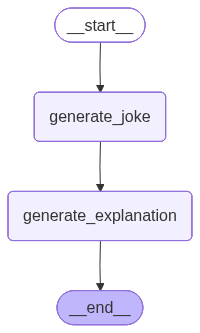

In [18]:
workflow

In [21]:
# Execute the workflow.

# initial_state = {
#     'topic' : "Trading"
# }

# workflow.invoke(initial_state)

# Final State value

In [26]:
# workflow.get_state(config1)

In [24]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'trading', 'joke': '1. Why did the trader bring a ladder to work? To reach new highs!\n\n2. My stocks are like my coffee—strong, but a bit too bitter sometimes!\n\n3. Did you hear about the optimistic trader? He always buys the dip... of ice cream!\n\n4. Why do traders make terrible gardeners? Too much hedging!\n\n5. What do you call a day trader who loves nature? A stock and roll enthusiast!', 'explanation': 'These jokes play on financial terms and puns. They blend trading concepts with relatable scenarios, creating humor through wordplay and unexpected twists, like mixing investing with everyday life.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7201-2c3d-6ce2-8002-e3be5530b2ed'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-11-01T12:41:23.014735+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0b7200-fae8-6020-8001-7b0e46b5

# For intermediate level history.

In [29]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': '1. Why did the pizza maker become a therapist? He knew how to knead problems away!\n\n2. Pizza: the only love triangle that always ends in a slice!\n\n3. What type of person doesn’t like pizza? A weir-dough! \n\n4. Why did the pizza party go the extra mile? It wanted to deliver good times!\n\n5. How does pizza introduce itself? "Slice to meet you!"', 'explanation': 'These pizza jokes use wordplay and puns to create humor. They cleverly combine pizza-related terms with everyday situations, resulting in light-hearted, relatable punchlines that play on the double meanings of words like "knead," "slice," and "dough."'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0b5e66-05d4-68e8-8002-65f0f1f05978'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-10-30T23:15:51.231687+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0

In [33]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'trading', 'joke': '1. Why did the trader bring a ladder? To reach new highs!  \n2. I told my stocks a joke – now they’re all in stitches!  \n3. Why don’t traders play hide and seek? Because good luck hiding from the market!  \n4. My portfolio has a great sense of humor; it always cracks me up!  \n5. Why did the market break up with the trader? Too many emotional trades!  ', 'explanation': 'These jokes play on trading terminology and humor, using puns and wordplay to relate financial concepts like "highs," "stocks," and "emotional trading" in a lighthearted way.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0b5e72-4546-6164-8006-0cccabe1f1f4'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2025-10-30T23:21:20.006743+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0b5e72-3776-6098-8005-815672fa6449'}}, tasks=(), interrupts=()),
 State

# Time Travel

In [27]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f06cc6e-7232-6cb1-8000-f71609e6cec5'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [28]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5"}})

EmptyInputError: Received no input for __start__

In [ ]:
list(workflow.get_state_history(config1))

# Updating State

In [ ]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc6e-7232-6cb1-8000-f71609e6cec5", "checkpoint_ns": ""}}, {'topic':'samosa'})

In [ ]:
list(workflow.get_state_history(config1))

In [ ]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f06cc72-ca16-6359-8001-7eea05e07dd2"}})

In [ ]:
list(workflow.get_state_history(config1))